In [10]:
import warnings
warnings.filterwarnings("ignore")


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import Dataset as HFDataset

import pandas as pd

In [16]:
# Load the CSV file
df = pd.read_csv("/Users/kundansingh/Downloads/Sentiment_Data.csv", encoding="ISO-8859-1")

# Encode sentiment column
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["Sentiment_Label"] = encoder.fit_transform(df["Sentiment"])


In [17]:
# Replace sentiment categories with three main labels
df["Sentiment"] = df["Sentiment"].replace({
    'Mild_Neg': 'Negative', 
    'Strong_Neg': 'Negative',
    'Mild_Pos': 'Positive',
    'Strong_Pos': 'Positive'
})

sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df["Sentiment_Label"] = df["Sentiment"].map(sentiment_mapping)

df_balanced = df.groupby("Sentiment").sample(n=2000, random_state=42)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


In [18]:
# Preprocessing imports and setup
import re
import nltk
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

slang_dict = {"u": "you", "r": "are", "ur": "your", "b4": "before"}

def preprocess_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|ftp\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = emoji.replace_emoji(text, replace="")
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = " ".join([slang_dict.get(word, word) for word in text.split()])
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df_balanced["Processed_Tweet"] = df_balanced["Tweet"].apply(preprocess_tweet)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kundansingh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kundansingh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kundansingh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
df_balanced

,Tweet,Sentiment,Sentiment_Label,Processed_Tweet
0,Ottawa police ban bringing supplies to trucker...,Negative,0,ottawa police ban bringing supply trucker free...
1,@acoyne I know it is a bit late - but I like t...,Neutral,1,know bit late like see others ie poster using ...
2,Some of the dumbest shit Iâve seen in Twitte...,Negative,0,dumbest shit iâve seen twitter recent month fr...
3,#FreedomConvoy \n#FascismHasComeToCanada \n#Ne...,Neutral,1,freedomconvoy fascismhascometocanada nevervote...
4,"Bitcoin Fundraising Canada, Ottawa Truckers Fr...",Positive,2,bitcoin fundraising canada ottawa trucker free...
...,...,...,...,...
5995,Brand new video is here and the sassitude is o...,Neutral,1,brand new video sassitude chain ðââïðââïðââï g...
5996,Did US Truckers Join Canadian 'Freedom Convoy'...,Positive,2,u trucker join canadian freedom convoy cdnpoli...
5997,@Patricia_Ann_E We have an emerging gun cultur...,Positive,2,emerging gun culture freedom arm lot âconvoyâ ...
5998,@globalnews @CTVNews @AndrewLawton well indigo...,Positive,2,well indigo isnât selling book andrew âfreedom...


In [20]:
# Splitting dataset
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_balanced, test_size=0.20, stratify=df_balanced["Sentiment_Label"], random_state=42)


In [7]:
pip install sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [21]:
# Use a model with relative position embeddings
MODEL_NAME = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)



MAX_LENGTH = 128  

def tokenize_function(examples):
    return tokenizer(examples["Processed_Tweet"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

hf_train_dataset = HFDataset.from_pandas(train_df)
hf_test_dataset = HFDataset.from_pandas(test_df)

train_tokenized = hf_train_dataset.map(tokenize_function, batched=True)
test_tokenized = hf_test_dataset.map(tokenize_function, batched=True)

train_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "Sentiment_Label"])
test_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "Sentiment_Label"])


/Users/kundansingh/anaconda3/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:558: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/4800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

In [22]:
class SentimentDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.dataset['input_ids'][idx]),
            'attention_mask': torch.tensor(self.dataset['attention_mask'][idx]),
            'labels': torch.tensor(self.dataset['Sentiment_Label'][idx])
        }

train_dataloader = DataLoader(SentimentDataset(train_tokenized), batch_size=32, shuffle=True)
test_dataloader = DataLoader(SentimentDataset(test_tokenized), batch_size=32, shuffle=False)


In [36]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

def train_model(model, train_dataloader, epochs=3):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_dataloader)}")

import time
start_time = time.time()
train_model(model, train_dataloader)
end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(self.dataset['input_ids'][idx]),
/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tens

Epoch 1, Loss: 0.8970116531848907
Epoch 2, Loss: 0.6887105818589528
Epoch 3, Loss: 0.5585143427054088
Training time: 2788.03 seconds


## Train Metrics

In [14]:
def evaluate_model(model, dataloader):
    model.eval()  # Set model to evaluation mode
    predictions = []
    true_labels = []
    
    with torch.no_grad():  # Disable gradient calculations
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)

            # Ensure correct dimensions for classification
            logits = outputs.logits  # Output logits directly
            preds = torch.argmax(logits, dim=-1)  # Get predicted class
            
            predictions.extend(preds.cpu().numpy())  # Convert to numpy
            true_labels.extend(labels.cpu().numpy())

    return true_labels, predictions

# Get predictions for training set
y_true_train, y_pred_train = evaluate_model(model, train_dataloader)

# Print classification report
from sklearn.metrics import classification_report
print("Classification Report for Training Set:")
print(classification_report(y_true_train, y_pred_train, target_names=["Negative", "Neutral", "Positive"]))


Classification Report for Training Set:
              precision    recall  f1-score   support

    Negative       0.90      0.86      0.88      1600
     Neutral       0.85      0.81      0.83      1600
    Positive       0.87      0.96      0.91      1600

    accuracy                           0.87      4800
   macro avg       0.87      0.87      0.87      4800
weighted avg       0.87      0.87      0.87      4800



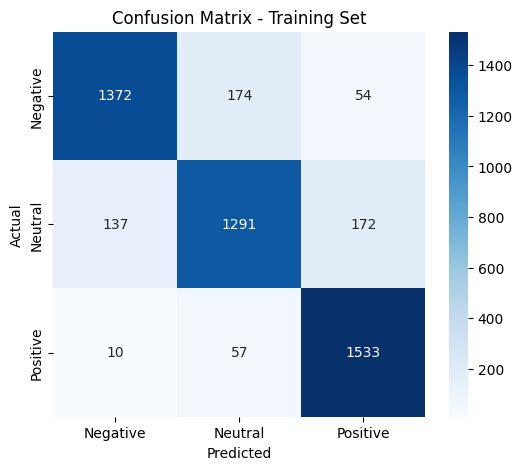

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_true_train, y_pred_train)

# Define class labels
class_labels = ["Negative", "Neutral", "Positive"]

# Plot confusion matrix using seaborn
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Training Set")
plt.show()


In [17]:
from sklearn.metrics import f1_score

# Function to get true and predicted labels
def get_predictions(model, dataloader):
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # Get raw logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()  # Convert to predicted labels

            predictions.extend(preds)
            true_labels.extend(labels)

    return true_labels, predictions

# Get predictions for the training set
y_true_train, y_pred_train = get_predictions(model, train_dataloader)

# Calculate F1-score for Positive (label 2) and Negative (label 0)
f1_positive = f1_score(y_true_train, y_pred_train, labels=[2], average="macro")
f1_negative = f1_score(y_true_train, y_pred_train, labels=[0], average="macro")

print(f"F1 Score for Positive Sentiment: {f1_positive:.4f}")
print(f"F1 Score for Negative Sentiment: {f1_negative:.4f}")


F1 Score for Positive Sentiment: 0.9128
F1 Score for Negative Sentiment: 0.8798


In [16]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

# Function to get probabilities instead of logits
def get_predictions_and_probs(model, dataloader):
    model.eval()
    predictions, true_labels, probs = [], [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].cpu().numpy()

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # Get logits
            probabilities = F.softmax(logits, dim=1)  # Convert logits to probabilities

            preds = torch.argmax(probabilities, dim=1).cpu().numpy()
            probs.extend(probabilities.cpu().numpy())  # Store probabilities
            predictions.extend(preds)
            true_labels.extend(labels)

    return true_labels, predictions, probs

# Get predictions and probabilities
y_true_train, y_pred_train, y_probs_train = get_predictions_and_probs(model, train_dataloader)

# Calculate AUC score
auc_score_train = roc_auc_score(y_true_train, y_probs_train, multi_class="ovr")  # One-vs-Rest AUC
print(f"AUC Score for Training Set: {auc_score_train:.4f}")


AUC Score for Training Set: 0.9659


In [18]:
from sklearn.metrics import accuracy_score

# Get predictions for the training set
y_true_train, y_pred_train = get_predictions(model, train_dataloader)

# Calculate accuracy
accuracy_train = accuracy_score(y_true_train, y_pred_train)

print(f"Training Accuracy: {accuracy_train:.4f}")


Training Accuracy: 0.8742


## Test Metrics

Classification Report for Test Set:
              precision    recall  f1-score   support

    Negative       0.78      0.72      0.75       400
     Neutral       0.69      0.68      0.68       400
    Positive       0.76      0.82      0.79       400

    accuracy                           0.74      1200
   macro avg       0.74      0.74      0.74      1200
weighted avg       0.74      0.74      0.74      1200



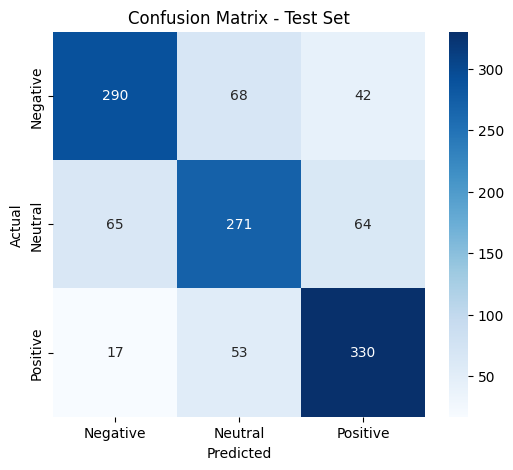

F1 Score for Positive Sentiment (Test Set): 0.7895
F1 Score for Negative Sentiment (Test Set): 0.7513
AUC Score for Test Set: 0.8981
Test Accuracy: 0.7425


In [19]:
# Get predictions and probabilities for the test set
y_true_test, y_pred_test, y_probs_test = get_predictions_and_probs(model, test_dataloader)

# Classification Report for Test Set
from sklearn.metrics import classification_report
print("Classification Report for Test Set:")
print(classification_report(y_true_test, y_pred_test, target_names=["Negative", "Neutral", "Positive"]))

# Generate confusion matrix for test set
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_test = confusion_matrix(y_true_test, y_pred_test)

# Plot confusion matrix for test set using seaborn
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

# Calculate F1 score for Positive (label 2) and Negative (label 0) for the test set
from sklearn.metrics import f1_score

f1_positive_test = f1_score(y_true_test, y_pred_test, labels=[2], average="macro")
f1_negative_test = f1_score(y_true_test, y_pred_test, labels=[0], average="macro")

print(f"F1 Score for Positive Sentiment (Test Set): {f1_positive_test:.4f}")
print(f"F1 Score for Negative Sentiment (Test Set): {f1_negative_test:.4f}")

# Calculate AUC score for the test set
from sklearn.metrics import roc_auc_score

auc_score_test = roc_auc_score(y_true_test, y_probs_test, multi_class="ovr")  # One-vs-Rest AUC
print(f"AUC Score for Test Set: {auc_score_test:.4f}")

# Calculate accuracy for the test set
from sklearn.metrics import accuracy_score

accuracy_test = accuracy_score(y_true_test, y_pred_test)

print(f"Test Accuracy: {accuracy_test:.4f}")


In [20]:
import pickle

# Save the model and optimizer state using pickle
def save_model_pickle(model, optimizer, filename="sentiment_model.pkl"):
    with open(filename, 'wb') as f:
        pickle.dump({
            'model': model,
            'optimizer': optimizer,
        }, f)
    print(f"Model saved to {filename}")

# Save the model and optimizer
save_model_pickle(model, optimizer, filename="sentiment_model.pkl")


Model saved to sentiment_model.pkl


In [24]:
import pickle

# Load the model and optimizer from a pickle file
def load_model_pickle(filename="sentiment_model.pkl"):
    with open(filename, 'rb') as f:
        checkpoint = pickle.load(f)
    model = checkpoint['model']
    optimizer = checkpoint['optimizer']
    print(f"Model loaded from {filename}")
    return model, optimizer

# Load the saved model and optimizer
model, optimizer = load_model_pickle(filename="sentiment_model.pkl")

# Move model to the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


Model loaded from sentiment_model.pkl


DebertaV2ForSequenceClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): StableDropout()
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-5): 6 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): StableDropout()
              (dropout): StableDropout()
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=T

## Model Tuning

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from transformers import BertTokenizer, BertForSequenceClassification
import nltk
from nltk.corpus import wordnet
import random

In [26]:
# Ensure NLTK wordnet is available
nltk.download("wordnet")

# Function to replace words with synonyms for Neutral class augmentation
def synonym_replacement(sentence, n=2):
    words = sentence.split()
    new_words = words.copy()
    random_indices = list(range(len(words)))
    random.shuffle(random_indices)
    
    for i in random_indices:
        synonyms = set()
        for syn in wordnet.synsets(words[i]):
            for lemma in syn.lemmas():
                synonyms.add(lemma.name())
        
        if synonyms:
            new_words[i] = random.choice(list(synonyms))
            n -= 1
            if n == 0:
                break

    return " ".join(new_words)

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kundansingh/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [27]:
# Assuming you have a dataset and data loader
# Augment Neutral class data
def augment_neutral_data(dataset):
    augmented_data = []
    for text, label in dataset:
        if label == 1:  # Neutral class
            augmented_text = synonym_replacement(text)
            augmented_data.append((augmented_text, label))
    return dataset + augmented_data

# Adjust model dropout (if applicable)
if hasattr(model.config, "hidden_dropout_prob"):
    model.config.hidden_dropout_prob = 0.2  # Increase dropout from 0.1 to 0.2
if hasattr(model.config, "attention_probs_dropout_prob"):
    model.config.attention_probs_dropout_prob = 0.2


In [28]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Adjust learning rate and implement scheduler
learning_rate = 3e-5
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = StepLR(optimizer, step_size=2, gamma=0.5)  # Reduce LR every 2 epochs


In [29]:
# Training loop
num_epochs = 5
model.train()

for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in train_dataloader:
        optimizer.zero_grad()
        
        input_ids, attention_mask, labels = (
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["labels"].to(device),
        )
        
        outputs = model(input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    accuracy = 100 * correct / total
    scheduler.step()  # Adjust learning rate

    print(
        f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}, Accuracy: {accuracy:.2f}%"
    )

/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(self.dataset['input_ids'][idx]),
/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(self.dataset['attention_mask'][idx]),
/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'labels': torch.tensor(self.d

Epoch [1/5], Loss: 55.7146, Accuracy: 86.23%
Epoch [2/5], Loss: 41.1583, Accuracy: 90.29%
Epoch [3/5], Loss: 29.4213, Accuracy: 93.52%
Epoch [4/5], Loss: 21.7297, Accuracy: 95.44%
Epoch [5/5], Loss: 17.8124, Accuracy: 96.52%


/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(self.dataset['input_ids'][idx]),
/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(self.dataset['attention_mask'][idx]),
/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'labels': torch.tensor(self.d


Training Set Metrics:
Training Accuracy: 0.9860
Training F1 Score (Macro): 0.9860
Training F1 Score (Weighted): 0.9860
Training AUC Score: 0.9979


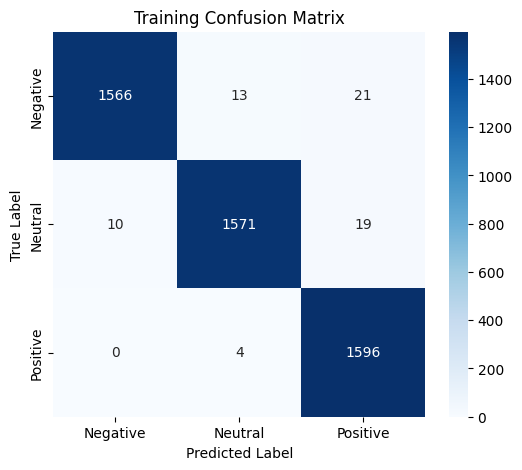

In [34]:
# Put model in evaluation mode
model.eval()

true_labels_train = []
predictions_train = []
probs_train = []

with torch.no_grad():
    for batch in train_dataloader:  # Use training data loader instead
        input_ids, attention_mask, labels = (
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["labels"].to(device),
        )
        
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        
        true_labels_train.extend(labels.cpu().numpy())
        predictions_train.extend(preds.cpu().numpy())
        probs_train.extend(torch.softmax(logits, dim=1).cpu().numpy())

# Convert lists to numpy arrays
true_labels_train = np.array(true_labels_train)
predictions_train = np.array(predictions_train)
probs_train = np.array(probs_train)

# Compute Metrics for Training Set
accuracy_train = accuracy_score(true_labels_train, predictions_train)
f1_macro_train = f1_score(true_labels_train, predictions_train, average="macro")
f1_weighted_train = f1_score(true_labels_train, predictions_train, average="weighted")
auc_score_train = roc_auc_score(true_labels_train, probs_train, multi_class="ovr")

# Print Training Metrics
print("\nTraining Set Metrics:")
print(f"Training Accuracy: {accuracy_train:.4f}")
print(f"Training F1 Score (Macro): {f1_macro_train:.4f}")
print(f"Training F1 Score (Weighted): {f1_weighted_train:.4f}")
print(f"Training AUC Score: {auc_score_train:.4f}")

# Confusion Matrix for Training Set
cm_train = confusion_matrix(true_labels_train, predictions_train)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Training Confusion Matrix")
plt.show()


/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(self.dataset['input_ids'][idx]),
/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(self.dataset['attention_mask'][idx]),
/var/folders/4b/1wrhs4hs295_0brtmft1r64r0000gn/T/ipykernel_61547/1209900391.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'labels': torch.tensor(self.d


Test Set Metrics:
Test Accuracy: 0.7292
Test F1 Score (Macro): 0.7311
Test F1 Score (Weighted): 0.7311
Test AUC Score: 0.8881

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.72      0.74       400
           1       0.64      0.71      0.67       400
           2       0.82      0.75      0.78       400

    accuracy                           0.73      1200
   macro avg       0.74      0.73      0.73      1200
weighted avg       0.74      0.73      0.73      1200



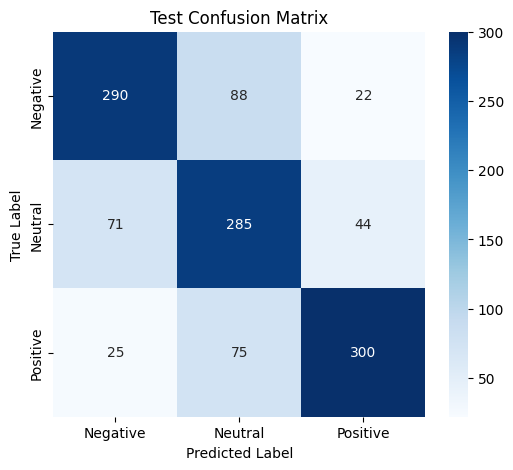

In [35]:
# Put model in evaluation mode
model.eval()

true_labels_test = []
predictions_test = []
probs_test = []

with torch.no_grad():
    for batch in test_dataloader:  # Use testing data loader
        input_ids, attention_mask, labels = (
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["labels"].to(device),
        )
        
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)
        
        true_labels_test.extend(labels.cpu().numpy())
        predictions_test.extend(preds.cpu().numpy())
        probs_test.extend(torch.softmax(logits, dim=1).cpu().numpy())

# Convert lists to numpy arrays
true_labels_test = np.array(true_labels_test)
predictions_test = np.array(predictions_test)
probs_test = np.array(probs_test)

# Compute Metrics for Test Set
accuracy_test = accuracy_score(true_labels_test, predictions_test)
f1_macro_test = f1_score(true_labels_test, predictions_test, average="macro")
f1_weighted_test = f1_score(true_labels_test, predictions_test, average="weighted")
auc_score_test = roc_auc_score(true_labels_test, probs_test, multi_class="ovr")

# Print Test Metrics
print("\nTest Set Metrics:")
print(f"Test Accuracy: {accuracy_test:.4f}")
print(f"Test F1 Score (Macro): {f1_macro_test:.4f}")
print(f"Test F1 Score (Weighted): {f1_weighted_test:.4f}")
print(f"Test AUC Score: {auc_score_test:.4f}")

# Classification Report for Test Set
print("\nClassification Report:\n", classification_report(true_labels_test, predictions_test))

# Confusion Matrix for Test Set
cm_test = confusion_matrix(true_labels_test, predictions_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Test Confusion Matrix")
plt.show()
